In [1]:
import os.path
from pathlib import Path
from PIL import Image

import numpy as np

import torch
from pkg_resources import find_eggs_in_zip
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import functional as TF

In [2]:
DATA_ROOT='../../data/CUB_200_2011'
BATCH_SIZE=8
NUM_WORKERS = 4
EPOCHS=5
LR=0.005
MOMENTUM=0.9
WEIGHT_DECAY=0.0001

IMG_SIZE=512
N_CLASSES=2
IGNORE_INDEX=255

In [6]:
def make_transform(train):
    def _tfm(img,mask):
        img= TF.resize(img,(IMG_SIZE,IMG_SIZE))
        mask= TF.resize(mask,(IMG_SIZE,IMG_SIZE),interpolation=TF.InterpolationMode.NEAREST)
        if train and torch.rand(1)<0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485,0.456,0.406], [0.229,0.224,0.225])
        mask=torch.as_tensor(np.array(mask),dtype=torch.long)
        return img,mask
    return _tfm

class CUBBinarySg(Dataset):
    def __init__(self, root, img_id, id2path, tf=None):
        self.root = Path(root)
        self.ids = img_id
        self.id2path = id2path
        self.tf = tf
        self.img_dir = self.root/'images'
        self.seg_dir = self.root/'segmentations'

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        img_idx = self.ids[idx]
        img_path = self.id2path[img_idx]
        img_path_call = self.img_dir/img_path
        img = Image.open(img_path_call).convert('RGB')

        sg_path_call = (self.seg_dir/img_path).with_suffix('.png')
        mask = Image.open(sg_path_call)
        mask_np = np.array(mask)
        mask_np = (mask_np>0).astype(np.uint8)
        mask = Image.fromarray(mask_np)

        if self.tf:
            img, mask = self.tf(img, mask)
        return img, mask

def read_id_to_path(root):
    id2path = {}
    with open(os.path.join(root, 'images.txt'), 'r') as f:
        for i in f:
            idx, p = i.strip().split(' ')
            id2path[int(idx)] = p
    return id2path

def read_tr_test_split(root):
    split = {}
    with open(os.path.join(root, 'train_test_split.txt'), 'r') as f:
        for i in f:
            idx, is_train = i.strip().split(' ')
            split[int(idx)]=int(is_train)
    return split

def get_loaders():
    root = DATA_ROOT
    ck_l = [
        os.path.join(root, 'images.txt'),
        os.path.join(root, 'train_test_split.txt'),
        os.path.join(root, 'images')
    ]
    for i in ck_l:
        if not (os.path.exists(i) and (os.path.isdir(i) or os.path.isfile(i))):
            raise FileNotFoundError(f'{i}파일 없음')

    id2path = read_id_to_path(root)
    split = read_tr_test_split(root)

    tr_ids = [i for i, t in split.items() if t==1]
    val_ids = [i for i, t in split.items() if t==0]

    tr_ds = CUBBinarySg(root, tr_ids, id2path, tf=make_transform(train=True))
    val_ds = CUBBinarySg(root, val_ids, id2path, tf=make_transform(train=False))
    tr_ds_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
    val_ds_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    return tr_ds, val_ds, tr_ds_loader, val_ds_loader
tr_ds, val_ds, tr_ds_loader, val_ds_loader = get_loaders()

In [7]:
import matplotlib.pyplot as plt

BG_COLOR = np.array([50, 50, 50], dtype=np.uint8)
BIRD_COLOR = np.array([200, 50, 50], dtype=np.uint8)
IGNORE_COLOR = np.array([100, 100, 100], dtype=np.uint8)

def _denorm(img):
    mean = torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std = torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1)
    return img.detach().cpu().numpy().transpose(1, 2, 0)

def _colorize_binary(mask_np,ignore_idx=255):
    out = np.zeros((*mask_np.shape,3), dtype=np.uint8)
    out[mask_np == 0]=BG_COLOR
    out[mask_np == 1]=BIRD_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

def overlay_mask(img_np, mask_rgb, alpha=0.5):
    base = (img_np*255).astype(np.uint8)
    over = (alpha*mask_rgb + (1-alpha)*base).astype(np.uint8)
    return over

def show_img_mask(ds, indices=None, n=6, alpha=0.5, ignore_idx=255):
    if indices is None:
        import random
        n = min(n, len(ds))
        indices = random.sample(range(len(ds)),k=n)
    else:
        n = len(indices)
    r, c = n, 3
    plt.figure(figsize=(c*4, r*3.5))

    for i, idx in enumerate(indices):
        sample = ds[idx]
        if len(sample) == 3:
            img, mask, id_ =sample
        else:
            img, mask = sample
        img_np = _denorm(img)
        mask_np = np.array(mask)
        mask_rgb = _colorize_binary(mask_np, ignore_idx)
        over = overlay_mask(img_np, mask_rgb, alpha)

        base = i * 3
        plt.subplot(r, c, base+1)
        plt.imshow(img_np)
        plt.title('img')
        plt.axis('off')

        plt.subplot(r, c, base+2)
        plt.imshow(mask_rgb)
        plt.title('mask')
        plt.axis('off')

        plt.subplot(r, c, base+3)
        plt.imshow(over)
        plt.title('overlay')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

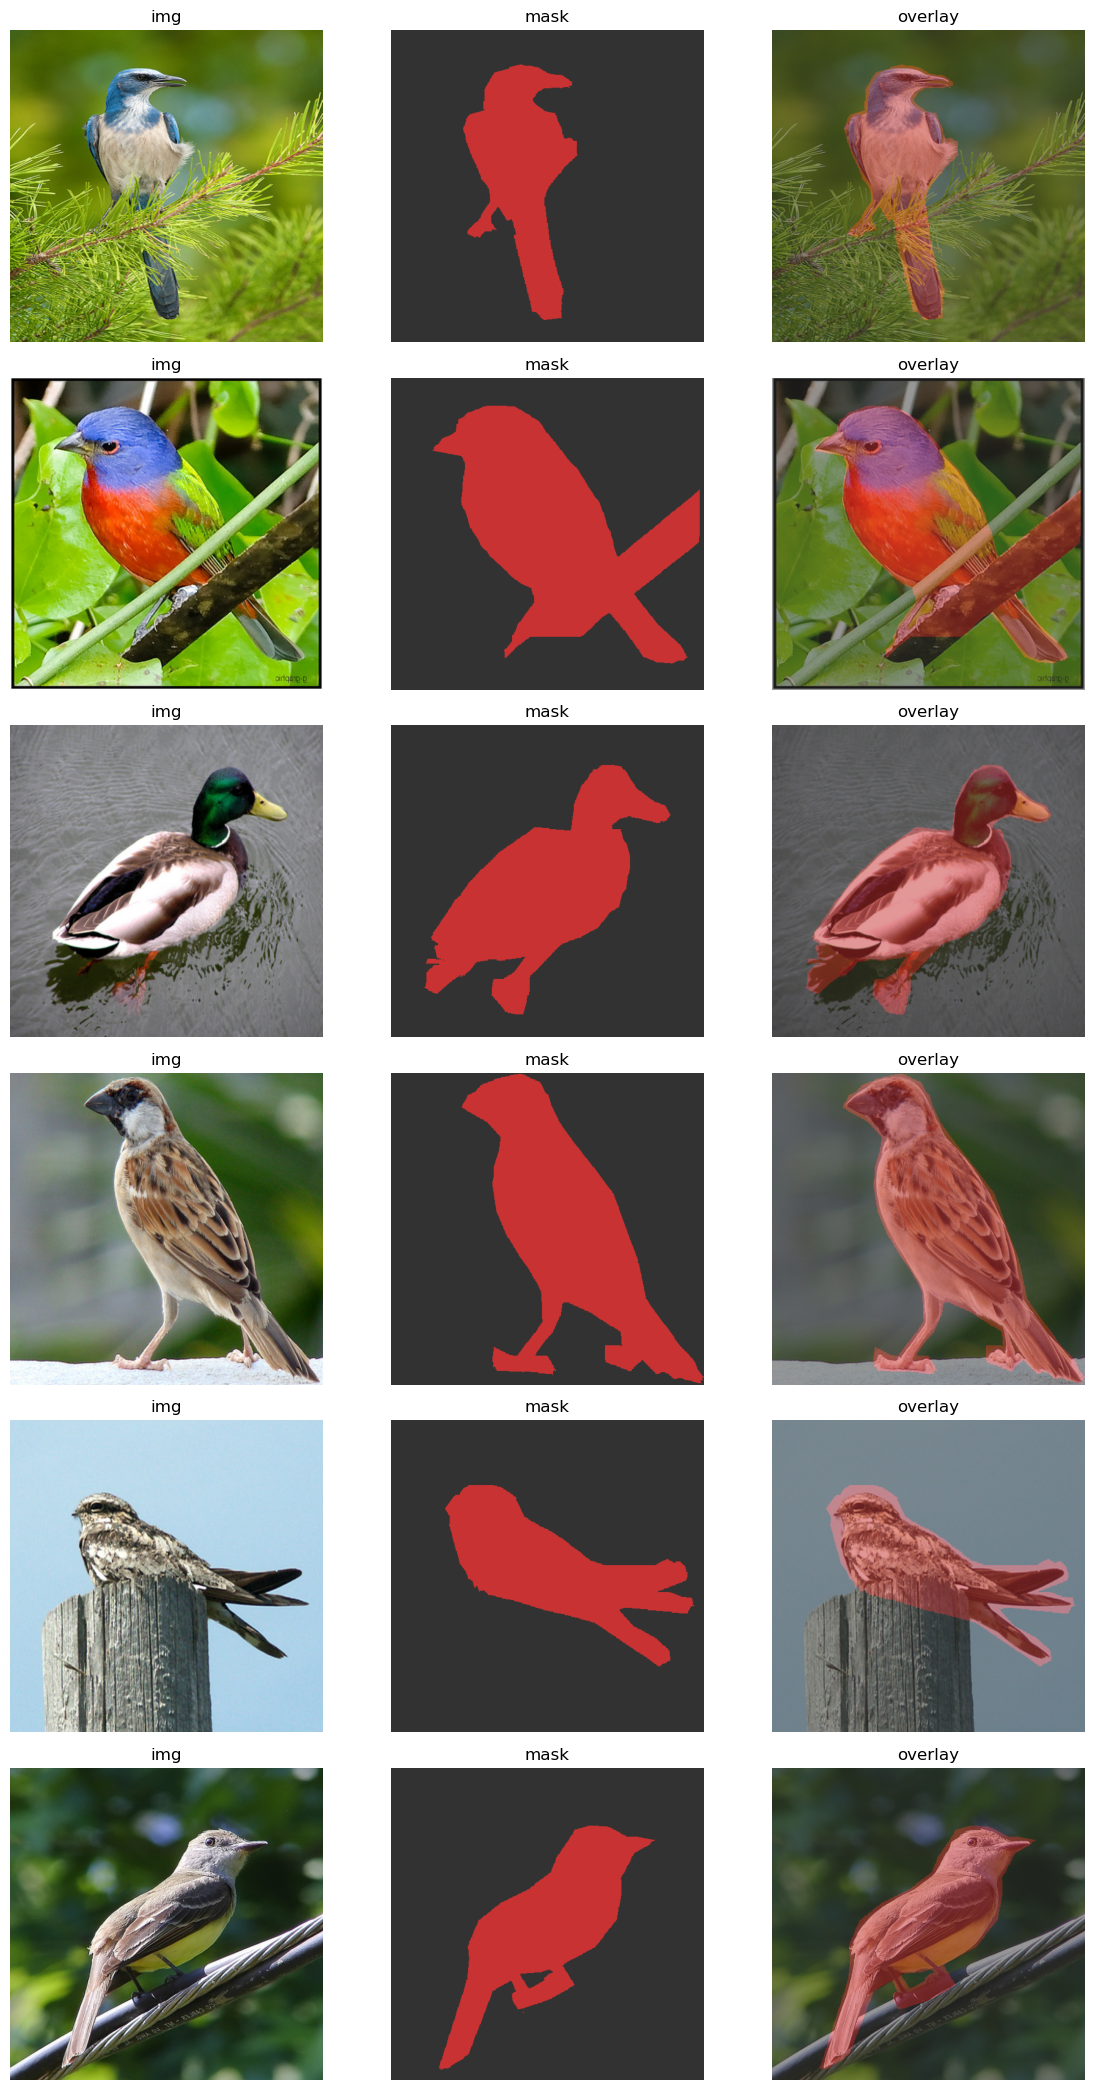

In [8]:
show_img_mask(tr_ds, n=6)

In [19]:
img = Image.open('../../data/CUB_200_2011/segmentations/001.Black_footed_Albatross/Black_Footed_Albatross_0001_796111.png')

In [21]:
np.unique(img.convert('L'))

array([  0,  51, 102, 153, 204, 255], dtype=uint8)

In [14]:
np.unique(img)

array([  0,  51, 102, 153, 204, 255], dtype=uint8)

In [16]:
ck_img = Image.open('../../data/VOCdevkit/VOC2012/SegmentationClass/2007_000032.png')

In [17]:
np.unique(ck_img)

array([  0,   1,  15, 255], dtype=uint8)

In [22]:
np.unique(ck_img.convert('L'))

array([  0,  38, 147, 220], dtype=uint8)